# Check-in 3 — Brain MRI Tumor Classification
**AME 34351 | Dublin Summer 2026**

**Educational prototype only — not a medical diagnostic tool.**

---
## Section 0 — Configuration

Centralizes paths, seeds, and flags. Figures → `outputs/`; dataset → `../data/` or Kaggle.

In [ ]:
import hashlib, json, os, random, warnings
from pathlib import Path
import matplotlib
try:
    get_ipython()
except NameError:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.decomposition import TruncatedSVD
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, log_loss, precision_score, recall_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

NOTEBOOK_DIR = Path('.').resolve()
if NOTEBOOK_DIR.name != 'deliverable3' and (NOTEBOOK_DIR / 'deliverable3').is_dir():
    NOTEBOOK_DIR = NOTEBOOK_DIR / 'deliverable3'
REPO_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / 'data').is_dir() else NOTEBOOK_DIR
OUTPUT_DIR = NOTEBOOK_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_FILE = OUTPUT_DIR / 'split_indices.json'
RANDOM_SEED, IMG_SIZE = 42, (128, 128)
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
FINAL_EVAL = True
RUN_CNN = True  # set True in Colab + GPU
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
print('OUTPUT_DIR:', OUTPUT_DIR)

OUTPUT_DIR: /content/outputs


**Note.** Set `RUN_CNN=True` in Section 0 (Colab + GPU) to train both CNNs in Section 14. Keep `FINAL_EVAL=False` until one final test evaluation.


**Note.** The 1,600-image test set stays locked until you set `FINAL_EVAL=True` once, after all model choices are frozen.


---
## Section 1 — Dataset Source and Release
*(from Deliverable 2, wording fixed per professor feedback)*

The **Brain Tumor MRI Dataset (V2)** by Masoud NickParvar (Kaggle) merges Figshare, SARTAJ, and Br35H sources.

The creator reports: duplicates removed, classes balanced, no train/test image overlap. **We have not independently verified patient-level separation** — patient IDs are not provided (see Section 17).

**Citation:** NickParvar, M. (2021). Brain Tumor MRI Dataset. https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

---
## Section 2 — Load Data

Uses local `../data/` when present; otherwise `kagglehub`.

In [ ]:
def resolve_data_root():
    local = REPO_ROOT / 'data'
    if (local / 'Training').is_dir() and (local / 'Testing').is_dir():
        return local
    import kagglehub
    path = kagglehub.dataset_download('masoudnickparvar/brain-tumor-mri-dataset')
    for root, dirs, _ in os.walk(path):
        if 'Training' in dirs and 'Testing' in dirs:
            return Path(root)
    raise FileNotFoundError('Training/Testing not found')

DATA_ROOT = resolve_data_root()
TRAIN_DIR, TEST_DIR = DATA_ROOT / 'Training', DATA_ROOT / 'Testing'
print('DATA_ROOT:', DATA_ROOT)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
DATA_ROOT: /kaggle/input/brain-tumor-mri-dataset


**Summary.** All **7,200** images loaded (5,600 train + 1,600 test). Labels come from folder names — no separate CSV.


---
## Section 3 — Dataset Size and Target Variable
*(Deliverable 2 Sections 3–4, combined)*

In [ ]:
def count_images(root):
    return {c: len([f for f in (root/c).iterdir() if f.suffix.lower() in {'.jpg','.jpeg','.png'}]) for c in CLASSES}

def load_paths_and_labels(root):
    paths, labels = [], []
    for c in CLASSES:
        for f in sorted((root/c).iterdir()):
            if f.suffix.lower() in {'.jpg','.jpeg','.png'}:
                paths.append(str(f)); labels.append(CLASS_TO_IDX[c])
    return paths, labels

train_counts, test_counts = count_images(TRAIN_DIR), count_images(TEST_DIR)
train_paths, train_labels = load_paths_and_labels(TRAIN_DIR)
test_paths, test_labels = load_paths_and_labels(TEST_DIR)

print(f"{'Class':<12} {'Train':>6} {'Test':>6} {'Total':>6}")
for c in CLASSES:
    print(f"{c:<12} {train_counts[c]:>6} {test_counts[c]:>6} {train_counts[c]+test_counts[c]:>6}")
print(f"{'TOTAL':<12} {sum(train_counts.values()):>6} {sum(test_counts.values()):>6} {len(train_paths)+len(test_paths):>6}")

Class         Train   Test  Total
glioma         1400    400   1800
meningioma     1400    400   1800
notumor        1400    400   1800
pituitary      1400    400   1800
TOTAL          5600   1600   7200


**Observation.** Each class has **1,400 train** and **400 test** images. Perfect balance means the majority baseline is exactly **25%** accuracy — any real signal must beat that clearly.


**Target:** multi-class label from folder name — `glioma`, `meningioma`, `notumor`, `pituitary`.

| Label | Class | Description |
|---|---|---|
| 0 | glioma | Glial-cell tumor; variable location |
| 1 | meningioma | Usually meningeal, near surface |
| 2 | notumor | No detectable tumor |
| 3 | pituitary | Pituitary-region tumor |

---
## Section 4 — Features and Preprocessing Specification
*(Deliverable 2 Section 5, unified — fixes inconsistent 64×64 vs 224×224 in D2)*

| Step | Specification |
|---|---|
| Input | 2D grayscale MRI |
| Raw sizes | Non-uniform (see Section 5) |
| Resize | 128x128, LANCZOS |
| Normalize | ÷ 255 → [0, 1] |
| Baselines | Flatten → 50,176 features; scaler fit on train-fit only |
| CNN | Shape (128, 128, 1); augmentation on train-fit only |

---
## Section 5 — Data Audit and Raw Dimensions
*(Replaces D2 Sections 5–6 + partial Viz 3 — single pass over all 7,200 images)*

In [ ]:
def audit_raw_images(paths):
    rows, corrupted, missing = [], [], []
    for p in paths:
        if not os.path.exists(p): missing.append(p); continue
        try:
            with Image.open(p) as im: w, h, mode = im.size[0], im.size[1], im.mode
            rows.append({'path': p, 'width': w, 'height': h, 'mode': mode})
        except Exception: corrupted.append(p)
    return pd.DataFrame(rows), corrupted, missing

all_paths = train_paths + test_paths
audit_df, corrupted, missing = audit_raw_images(all_paths)
audit_df['class'] = audit_df['path'].apply(lambda p: Path(p).parent.name)
print('Audited:', len(audit_df), '| Missing:', len(missing), '| Corrupted:', len(corrupted))
print('Width  min/max/mean:', audit_df['width'].min(), audit_df['width'].max(), round(audit_df['width'].mean(),1))
print('Height min/max/mean:', audit_df['height'].min(), audit_df['height'].max(), round(audit_df['height'].mean(),1))
print('Unique (w,h) pairs:', audit_df.groupby(['width','height']).ngroups)
print('Top sizes:\n', audit_df.groupby(['width','height']).size().sort_values(ascending=False).head(3))

Audited: 7200 | Missing: 0 | Corrupted: 0
Width  min/max/mean: 150 1375 453.3
Height min/max/mean: 167 1446 456.9
Unique (w,h) pairs: 447
Top sizes:
 width  height
512    512       5014
225    225        338
630    630         90
dtype: int64


**Observation.** **5,014** of 7,200 images are 512×512, but **447** unique (width×height) pairs exist. Resizing to 128×128 is mandatory before modeling for consistency in the images. This is done in section 10 and 10.5.


---
## Section 6 — Duplicate Check *(new in D3 — addresses provenance feedback)*

In [ ]:
def file_md5(path, block=65536):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(block), b''): h.update(chunk)
    return h.hexdigest()

hashes, cross_split_dups = {}, []
for split_name, paths in [('train', train_paths), ('test', test_paths)]:
    for p in paths:
        d = file_md5(p)
        if d in hashes and hashes[d]['split'] != split_name:
            cross_split_dups.append((hashes[d]['path'], p))
        hashes[d] = {'path': p, 'split': split_name}
print('Cross train/test duplicate pairs:', len(cross_split_dups))

Cross train/test duplicate pairs: 0


**Key insight.** **0** cross-split duplicate pairs (MD5) — supports the creator's file-level no-overlap claim. Patient-level independence is still unverified (no patient IDs).


---
## Section 7 — Interactive Class Explorer
*(Deliverable 2 Section 7 — unchanged)*

In [ ]:
def show_class_samples(cls_name, n=10, split='Training'):
    root = TRAIN_DIR if split == 'Training' else TEST_DIR
    files = sorted([f for f in (root/cls_name).iterdir() if f.suffix.lower() in {'.jpg','.jpeg','.png'}])[:n]
    fig, axes = plt.subplots(2, 5, figsize=(14, 5))
    for ax, fp in zip(axes.ravel(), files):
        ax.imshow(Image.open(fp).convert('L'), cmap='gray'); ax.axis('off')
    fig.suptitle(f'{split} — {cls_name}'); plt.tight_layout(); plt.show()

try:
    get_ipython()
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    dd = widgets.Dropdown(options=CLASSES, description='Class:')
    sp = widgets.RadioButtons(options=['Training','Testing'], description='Split:')
    out = widgets.Output()
    def _on(change):
        with out: clear_output(wait=True); show_class_samples(dd.value, split=sp.value)
    dd.observe(_on, names='value'); sp.observe(_on, names='value')
    display(widgets.HBox([dd, sp]), out); _on(None)
except (NameError, ImportError):
    print('Headless / no ipywidgets — showing static glioma training samples')
    show_class_samples('glioma', split='Training')

Output()

**Comment.** Glioma and meningioma thumbnails look alike at this scale — consistent with later confusion-matrix errors between those classes.


---
## Section 8 — Exploratory Data Analysis
Four visualizations, each answering one independant question. The last visualization looks specifically at the brightness and contrast of each image and places them on a box plot. This information is later useful in SVD baseline model training.

**Conclusion (split audit).** Zero MD5 duplicates across train / validation / test supports file-level independence. We still lack patient IDs, so we cannot rule out multiple slices from the same patient appearing in different splits — a known limitation of this public benchmark.


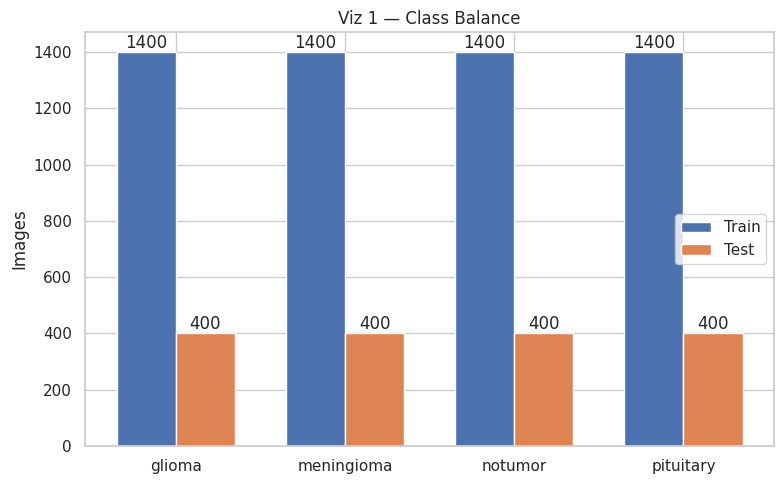

In [ ]:
# Viz 1 — Class balance (D2 Viz 1)
fig, ax = plt.subplots(figsize=(8, 5))
x, w = np.arange(len(CLASSES)), 0.35
b1 = ax.bar(x-w/2, [train_counts[c] for c in CLASSES], w, label='Train', color='#4C72B0')
b2 = ax.bar(x+w/2, [test_counts[c] for c in CLASSES], w, label='Test', color='#DD8452')
ax.set_xticks(x); ax.set_xticklabels(CLASSES); ax.set_ylabel('Images')
ax.set_title('Viz 1 — Class Balance'); ax.legend(); ax.bar_label(b1); ax.bar_label(b2)
plt.tight_layout(); plt.savefig(OUTPUT_DIR/'viz1_class_balance.png', dpi=150); plt.show()

**Summary.** Balanced classes → majority baseline = **25%** accuracy. Logistic regression later reaches **84.6%** on validation.

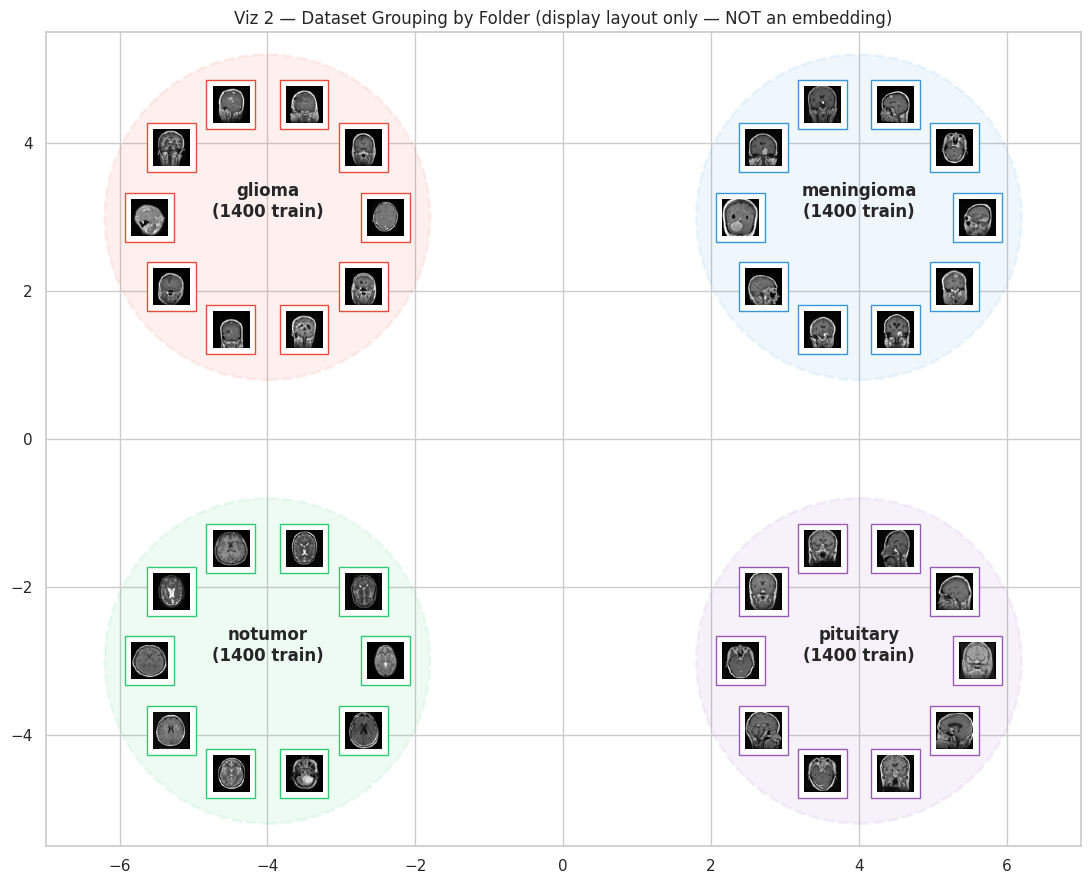

In [ ]:
# Viz 2 — Folder clusters (D2 Viz 2, display-only layout)
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from matplotlib.patches import Circle
CLASS_COLORS = {'glioma':'#E74C3C','meningioma':'#3498DB','notumor':'#2ECC71','pituitary':'#9B59B6'}
CENTERS = {'glioma':(-4,3),'meningioma':(4,3),'notumor':(-4,-3),'pituitary':(4,-3)}
rng = random.Random(RANDOM_SEED)
fig, ax = plt.subplots(figsize=(13, 9))
for cls in CLASSES:
    files = [f for f in (TRAIN_DIR/cls).iterdir() if f.suffix.lower() in {'.jpg','.jpeg','.png'}]
    sample = rng.sample(files, min(10, len(files)))
    cx, cy = CENTERS[cls]
    ax.add_patch(Circle((cx,cy), 2.2, fill=True, facecolor=CLASS_COLORS[cls], alpha=0.08, edgecolor=CLASS_COLORS[cls], lw=2, ls='--'))
    angles = np.linspace(0, 2*np.pi, len(sample), endpoint=False)
    for fp, ang in zip(sample, angles):
        thumb = np.asarray(Image.open(fp).convert('L').resize((48,48)), dtype=np.float32)/255
        xy = (cx+1.6*np.cos(ang), cy+1.6*np.sin(ang))
        ax.add_artist(AnnotationBbox(OffsetImage(thumb, zoom=0.55, cmap='gray'), xy, frameon=True,
            bboxprops=dict(edgecolor=CLASS_COLORS[cls], facecolor='white')))
    ax.annotate(f'{cls}\n({train_counts[cls]} train)', (cx,cy), ha='center', fontweight='bold')
ax.set_xlim(-7,7); ax.set_ylim(-5.5,5.5); ax.set_aspect('equal')
ax.set_title('Viz 2 — Dataset Grouping by Folder (display layout only — NOT an embedding)')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/'viz2_dataset_grouping.png', dpi=150); plt.show()

**Comment.** Viz 2 layout is hand-placed for display only (not PCA/t-SNE). Visual similarity between glioma and meningioma foreshadows baseline confusion.


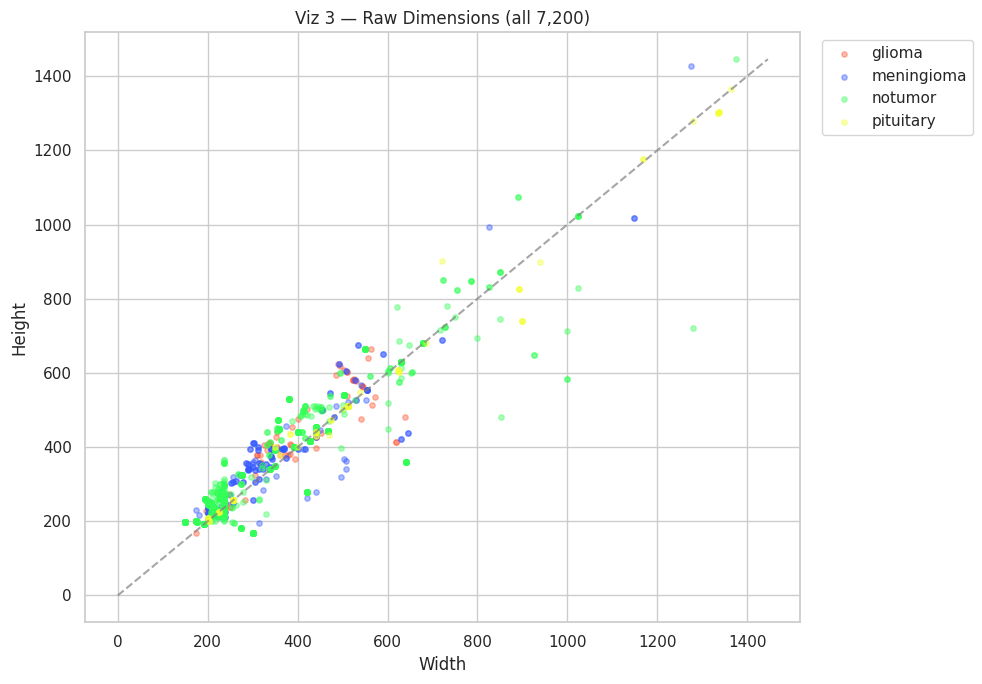

           width              height             
             min   max   mean    min   max   mean
class                                            
glioma       175   640  506.5    167   665  507.6
meningioma   174  1275  486.7    195  1427  489.2
notumor      150  1375  308.2    168  1446  319.5
pituitary    201  1365  511.7    202  1365  511.4


In [ ]:
# Viz 3 — Dimensions scatter + numeric table (D2 Viz 3 + professor feedback)
colors = {'glioma':'#FF5733','meningioma':'#3357FF','notumor':'#33FF57','pituitary':'#F3FF33'}
fig, ax = plt.subplots(figsize=(10, 7))
for cls in CLASSES:
    sub = audit_df[audit_df['class']==cls]
    ax.scatter(sub['width'], sub['height'], alpha=0.4, s=15, label=cls, color=colors[cls])
mx = max(audit_df['width'].max(), audit_df['height'].max())
ax.plot([0,mx],[0,mx],'--',color='gray',alpha=0.7)
ax.set_xlabel('Width'); ax.set_ylabel('Height'); ax.set_title('Viz 3 — Raw Dimensions (all 7,200)')
ax.legend(bbox_to_anchor=(1.02,1)); plt.tight_layout()
plt.savefig(OUTPUT_DIR/'viz3_dimensions.png', dpi=150); plt.show()
print(audit_df.groupby('class')[['width','height']].agg(['min','max','mean']).round(1))

**Key insight.** `notumor` slices are the smallest on average (~308×320 px), while glioma, meningioma, and pituitary sit near 487–512 px; `notumor` also shows the widest size spread. Standardizing to 128×128 reduces but does not remove scale effects.


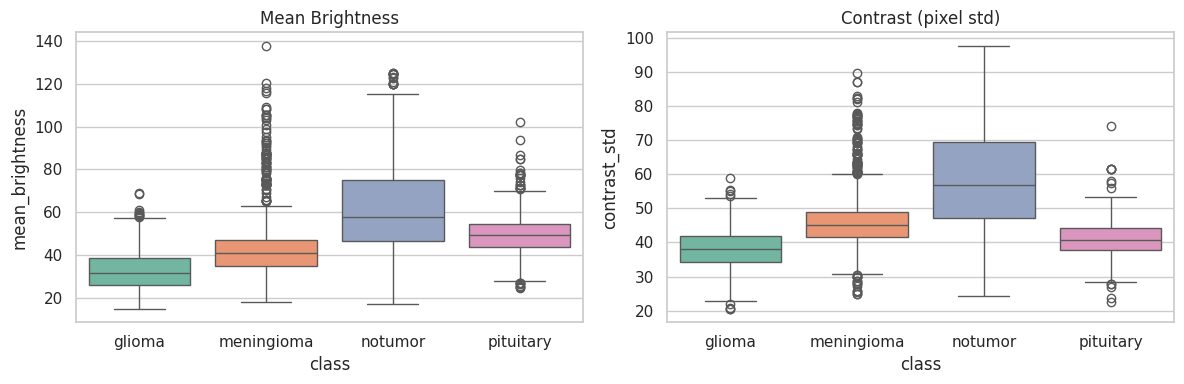

In [ ]:
# Viz 4 — Brightness/contrast by class (new — links to brightness baseline)
def raw_brightness(path):
    im = np.asarray(Image.open(path).convert('L').resize(IMG_SIZE, Image.Resampling.LANCZOS), dtype=np.float32)
    return im.mean(), im.std()
bright_df = pd.DataFrame([{'class':CLASSES[y], 'mean_brightness':raw_brightness(p)[0], 'contrast_std':raw_brightness(p)[1]}
    for p,y in zip(train_paths, train_labels)])
fig, axes = plt.subplots(1,2,figsize=(12,4))
sns.boxplot(data=bright_df,x='class',y='mean_brightness',ax=axes[0],palette='Set2')
sns.boxplot(data=bright_df,x='class',y='contrast_std',ax=axes[1],palette='Set2')
axes[0].set_title('Mean Brightness'); axes[1].set_title('Contrast (pixel std)')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/'viz4_brightness_contrast.png', dpi=150); plt.show()

**Observation.** Brightness histograms overlap across tumor types. A single threshold gives **0.857** binary F1 (tumor vs no-tumor) but cannot solve 4-class subtype classification.


---
## Section 9 — Locked Train / Validation / Test Split
*(D2 Section 11, fixed — no test use during tuning)*

In [ ]:
idx = np.arange(len(train_paths))
train_fit_idx, val_idx = train_test_split(idx, test_size=0.20, random_state=RANDOM_SEED, stratify=train_labels)
with open(SPLIT_FILE,'w') as f:
    json.dump({'random_seed':RANDOM_SEED,'train_fit_indices':train_fit_idx.tolist(),
        'val_indices':val_idx.tolist(),'n_train_fit':len(train_fit_idx),'n_val':len(val_idx),
        'n_test':len(test_paths)}, f, indent=2)
def subset(paths, labels, ix): return [paths[i] for i in ix], [labels[i] for i in ix]
tr_paths, tr_labels = subset(train_paths, train_labels, train_fit_idx)
va_paths, va_labels = subset(train_paths, train_labels, val_idx)
print(f'Train-fit {len(tr_paths)} | Val {len(va_paths)} | Test held {len(test_paths)}')

Train-fit 4480 | Val 1120 | Test held 1600


**Note.** The 1,600-image test set is never used until Section 16 with `FINAL_EVAL=True`. All tuning happens on train-fit; validation reports honest development metrics. All of this is done in an effort to prevent data leakage.


---
## Section 10 — Build Feature Tensors (Image Resizing)

In [ ]:
def load_image_array(path, size=IMG_SIZE):
    return np.asarray(Image.open(path).convert('L').resize(size, Image.Resampling.LANCZOS), dtype=np.float32)/255.0
paths_to_flat = lambda ps: np.array([load_image_array(p).ravel() for p in ps])
paths_to_cnn = lambda ps: np.array([load_image_array(p)[...,None] for p in ps])
X_tr, X_va = paths_to_flat(tr_paths), paths_to_flat(va_paths)
y_tr, y_va = np.array(tr_labels), np.array(va_labels)
print('Shapes:', X_tr.shape, X_va.shape)

Shapes: (4480, 16384) (1120, 16384)


**Summary.** Train-fit: **4,480** images → 50,176-d vectors (baselines) or 128×128×1 / RGB tensors (CNNs). Scaler fit on train-fit only.


# 10.5 - IMAGE RESIZING

Original image path: /kaggle/input/brain-tumor-mri-dataset/Training/glioma/Tr-gl_1.jpg
Resized image shape: (128, 128)


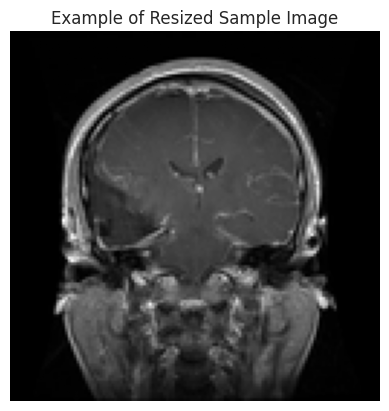

In [ ]:
# Example of using load_image_array to resize an image

# Get the path to a sample image (e.g., the first training image)
sample_image_path = train_paths[0]

# Load and resize the image
resized_image = load_image_array(sample_image_path)

print(f"Original image path: {sample_image_path}")
print(f"Resized image shape: {resized_image.shape}")

# You can display the resized image to visualize it
plt.imshow(resized_image, cmap='gray')
plt.title('Example of Resized Sample Image')
plt.axis('off')
plt.show()

---
## Section 11 — Baseline Models
*(D2 Section 12, fixed: metrics on **validation** only — professor deduction)*


=== Baseline 1 Majority === Acc 0.250 | P/R/F1 0.062/0.250/0.100


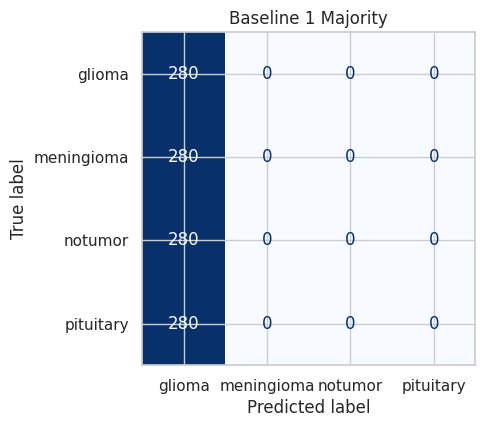

Brightness threshold (val): 0.0586, binary F1: 0.857

=== Baseline 3 Logistic Regression === Acc 0.846 | P/R/F1 0.845/0.846/0.845


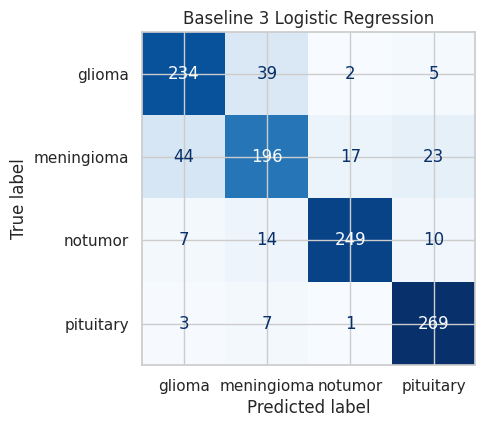


=== Baseline 4 SVD LR === Acc 0.790 | P/R/F1 0.789/0.790/0.789


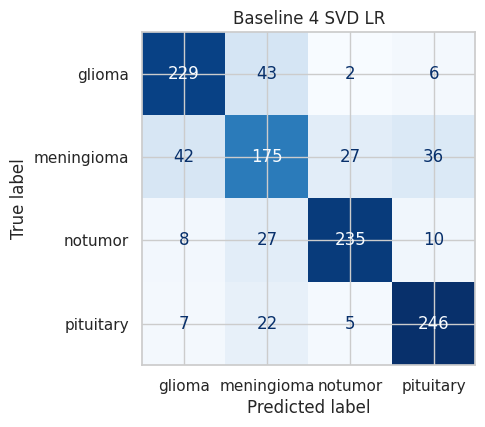

                                accuracy  precision  recall     f1
model                                                             
Baseline 1 Majority                0.250      0.062   0.250  0.100
Baseline 3 Logistic Regression     0.846      0.845   0.846  0.845
Baseline 4 SVD LR                  0.790      0.789   0.790  0.789


In [ ]:
def report_metrics(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f'\n=== {name} === Acc {acc:.3f} | P/R/F1 {prec:.3f}/{rec:.3f}/{f1:.3f}')
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
    fig, ax = plt.subplots(figsize=(5,5)); disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name); plt.tight_layout()
    safe = ''.join(c if c.isalnum() else '_' for c in name.lower())
    plt.savefig(OUTPUT_DIR/f'cm_{safe}.png', dpi=150); plt.show()
    return {'model':name,'accuracy':acc,'precision':prec,'recall':rec,'f1':f1}

results = []
dummy = DummyClassifier(strategy='most_frequent'); dummy.fit(X_tr, y_tr)
results.append(report_metrics('Baseline 1 Majority', y_va, dummy.predict(X_va)))

notumor_idx = CLASS_TO_IDX['notumor']; y_va_bin = (y_va != notumor_idx).astype(int)
mean_va = X_va.mean(axis=1)
best_t = max(np.linspace(mean_va.min(), mean_va.max(), 50),
    key=lambda t: f1_score(y_va_bin, (mean_va>t).astype(int), zero_division=0))
print(f'Brightness threshold (val): {best_t:.4f}, binary F1:',
      round(f1_score(y_va_bin,(mean_va>best_t).astype(int),zero_division=0),3))

scaler = StandardScaler(); X_tr_sc = scaler.fit_transform(X_tr); X_va_sc = scaler.transform(X_va)
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED); lr.fit(X_tr_sc, y_tr)
y_va_lr = lr.predict(X_va_sc)
results.append(report_metrics('Baseline 3 Logistic Regression', y_va, y_va_lr))

svd_lr = Pipeline([('scaler',StandardScaler()),('svd',TruncatedSVD(100, random_state=RANDOM_SEED)),
    ('clf',LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))])
svd_lr.fit(X_tr, y_tr); y_va_svd = svd_lr.predict(X_va)
results.append(report_metrics('Baseline 4 SVD LR', y_va, y_va_svd))

summary_df = pd.DataFrame(results).set_index('model')
summary_df.round(3).to_csv(OUTPUT_DIR/'baseline_validation_metrics.csv')
print(summary_df.round(3))

**Conclusion (baselines, validation n=1,120).**

- Majority class: **0.250** accuracy (exactly 25% with balanced labels).
- Logistic regression (raw pixels): **0.846** accuracy, F1 **0.845**, **172** misclassified.
- SVD (k=100) + LR: **0.790** — dimensionality reduction **hurts** here.
- Brightness-only binary classifier: F1 **0.857** for tumor vs no-tumor.

**Interesting fact.** Linear models on flattened pixels already beat chance by a wide margin, but subtype separation (glioma vs meningioma) remains the hard part — not tumor detection.

**Comment.** All metrics below are on the **1,120-image validation set** — not the held-out test set.


---
## Section 11b — Baseline Training Curves (Loss & Accuracy)

Logistic regression is refit with increasing `saga` iterations (`warm_start`) to visualize **cross-entropy loss** and **accuracy**. Curves use a **1,200-image stratified subsample** for speed (Section 11 metrics still use all 4,480 train-fit images).


LR curve: 8 checkpoints on 1200-image subsample (full val set for metrics)...
  saga max_iter=1...
  saga max_iter=5...
  saga max_iter=10...
  saga max_iter=20...
  saga max_iter=30...
  saga max_iter=50...
  saga max_iter=75...
  saga max_iter=100...


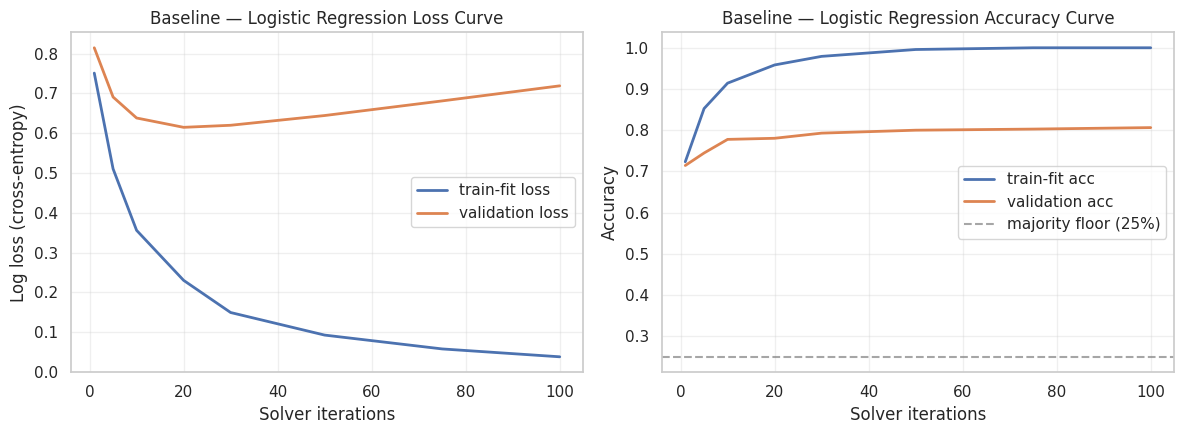

Final val loss: 0.719 | Final val acc: 0.806


In [ ]:
# Logistic regression learning curves (multinomial log-loss)
from sklearn.model_selection import StratifiedShuffleSplit
curve_idx = next(StratifiedShuffleSplit(n_splits=1, train_size=1200, random_state=RANDOM_SEED).split(X_tr_sc, y_tr))[0]
Xc, yc = X_tr_sc[curve_idx], y_tr[curve_idx]
iters = [1, 5, 10, 20, 30, 50, 75, 100]
tr_loss, va_loss, tr_acc, va_acc = [], [], [], []
lr_path = LogisticRegression(solver='saga', C=1.0, warm_start=True, max_iter=1, random_state=RANDOM_SEED)
print(f'LR curve: {len(iters)} checkpoints on {len(yc)}-image subsample (full val set for metrics)...')
for n in iters:
    print(f'  saga max_iter={n}...', flush=True)
    lr_path.max_iter = n
    lr_path.fit(Xc, yc)
    tr_loss.append(log_loss(yc, lr_path.predict_proba(Xc)))
    va_loss.append(log_loss(y_va, lr_path.predict_proba(X_va_sc)))
    tr_acc.append(accuracy_score(yc, lr_path.predict(Xc)))
    va_acc.append(accuracy_score(y_va, lr_path.predict(X_va_sc)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(iters, tr_loss, label='train-fit loss', color='#4C72B0', lw=2)
axes[0].plot(iters, va_loss, label='validation loss', color='#DD8452', lw=2)
axes[0].set_xlabel('Solver iterations'); axes[0].set_ylabel('Log loss (cross-entropy)')
axes[0].set_title('Baseline — Logistic Regression Loss Curve')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(iters, tr_acc, label='train-fit acc', color='#4C72B0', lw=2)
axes[1].plot(iters, va_acc, label='validation acc', color='#DD8452', lw=2)
axes[1].axhline(0.25, color='gray', ls='--', alpha=0.7, label='majority floor (25%)')
axes[1].set_xlabel('Solver iterations'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Baseline — Logistic Regression Accuracy Curve')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'baseline_lr_learning_curves.png', dpi=150)
plt.show()
print(f'Final val loss: {va_loss[-1]:.3f} | Final val acc: {va_acc[-1]:.3f}')

**Conclusion.** On the learning-curve subsample, validation log-loss (**0.719**) stayed above train-fit loss and validation accuracy (**0.806**) lagged the full-data logistic model (**0.846**). That gap is normal: the curve uses 1,200 images and fewer iterations, while Section 11 fits all 4,480 train-fit pixels. The takeaway is that LR already generalizes well — validation loss does not explode relative to training.

SVD sweep: 8 values of k...
  k=20...
  k=40...
  k=60...
  k=80...
  k=100...
  k=120...
  k=150...
  k=200...


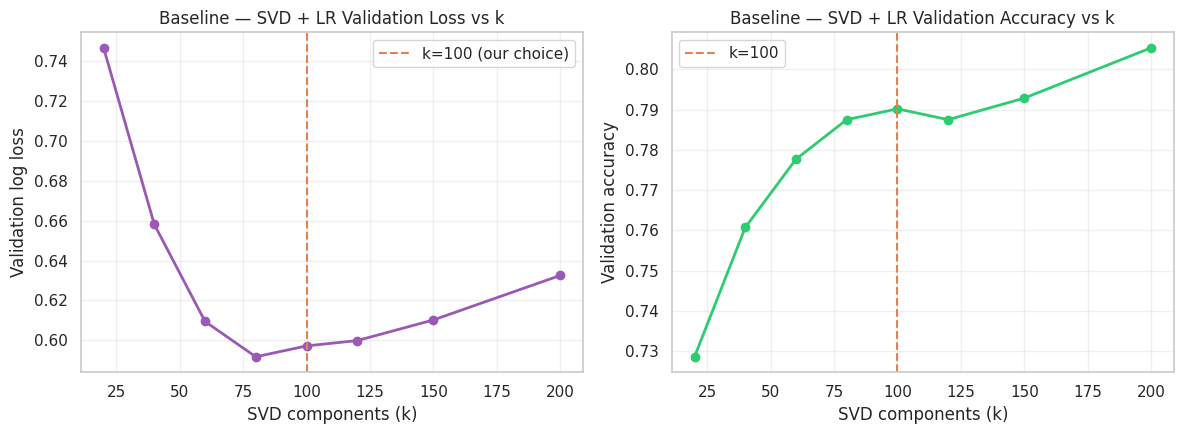

In [ ]:
# SVD baseline: validation log-loss vs number of components k
k_values = [20, 40, 60, 80, 100, 120, 150, 200]
svd_va_loss, svd_va_acc = [], []
print(f'SVD sweep: {len(k_values)} values of k...')
for k in k_values:
    print(f'  k={k}...', flush=True)
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svd', TruncatedSVD(k, random_state=RANDOM_SEED)),
        ('clf', LogisticRegression(max_iter=500, random_state=RANDOM_SEED)),
    ])
    pipe.fit(X_tr, y_tr)
    proba = pipe.predict_proba(X_va)
    svd_va_loss.append(log_loss(y_va, proba))
    svd_va_acc.append(accuracy_score(y_va, pipe.predict(X_va)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(k_values, svd_va_loss, 'o-', color='#9B59B6', lw=2)
axes[0].axvline(100, ls='--', color='#DD8452', label='k=100 (our choice)')
axes[0].set_xlabel('SVD components (k)'); axes[0].set_ylabel('Validation log loss')
axes[0].set_title('Baseline — SVD + LR Validation Loss vs k')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(k_values, svd_va_acc, 'o-', color='#2ECC71', lw=2)
axes[1].axvline(100, ls='--', color='#DD8452', label='k=100')
axes[1].set_xlabel('SVD components (k)'); axes[1].set_ylabel('Validation accuracy')
axes[1].set_title('Baseline — SVD + LR Validation Accuracy vs k')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'baseline_svd_loss_vs_k.png', dpi=150)
plt.show()

***REMARK:***   

For SVD in this notebook we use the variable K to represent the number of singular values used. This should not in anyway be confused with the number of clusters in a clustering algorithm since these are two different machine learning techniques

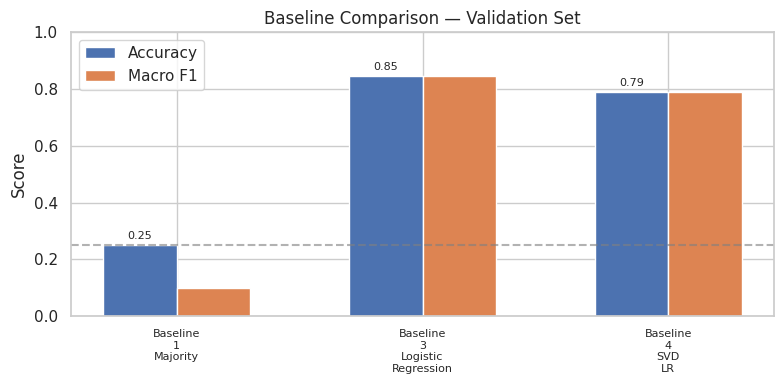

In [ ]:
# Side-by-side bar chart: all baselines on validation
fig, ax = plt.subplots(figsize=(8, 4))
models = summary_df.index.tolist()
x = np.arange(len(models))
ax.bar(x - 0.15, summary_df['accuracy'], 0.3, label='Accuracy', color='#4C72B0')
ax.bar(x + 0.15, summary_df['f1'], 0.3, label='Macro F1', color='#DD8452')
ax.set_xticks(x); ax.set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=8)
ax.set_ylim(0, 1); ax.set_ylabel('Score')
ax.set_title('Baseline Comparison — Validation Set')
ax.legend(); ax.axhline(0.25, color='gray', ls='--', alpha=0.6)
for i, v in enumerate(summary_df['accuracy']):
    ax.text(i - 0.15, v + 0.02, f'{v:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'baseline_comparison_bars.png', dpi=150)
plt.show()

**Observation.** LR learning curves: subsample val loss **0.719**, val acc **0.806**; full model val acc **0.846**. Train and val curves move together — no severe overfitting on pixels.

**Note.** Compiled run (seed 42): LR validation accuracy **0.846**, **172** errors. Re-run after code changes to verify.

---
## Section 12 — Combined Confusion Matrices and SVD Variance
*(D2 Sections 13–14, fixed: validation set)*

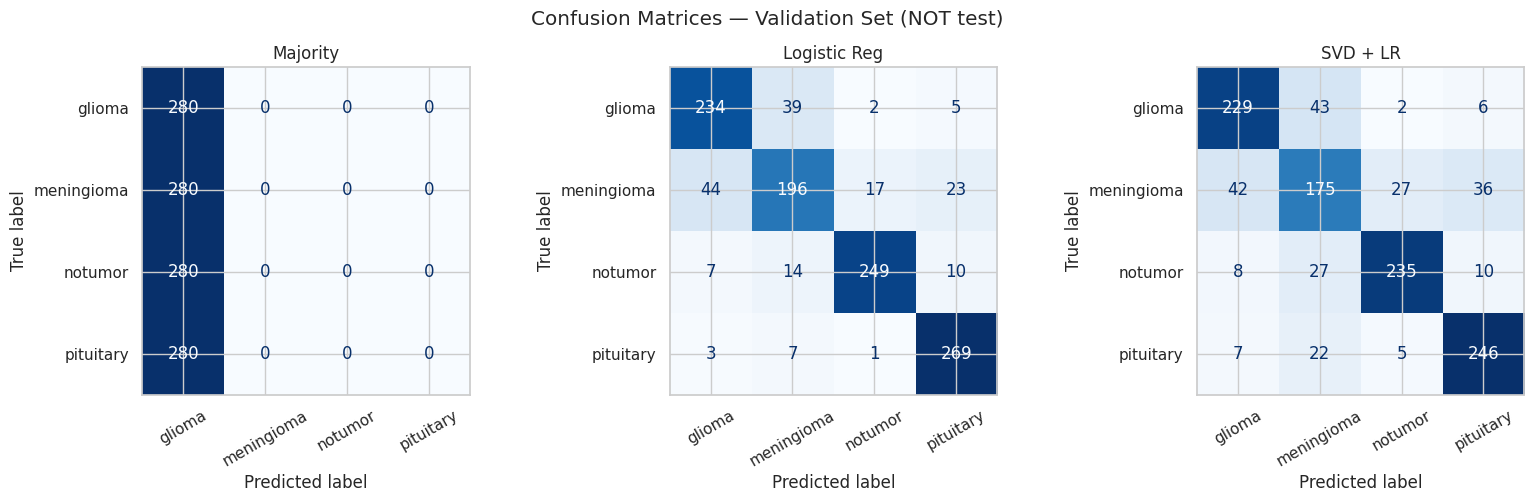

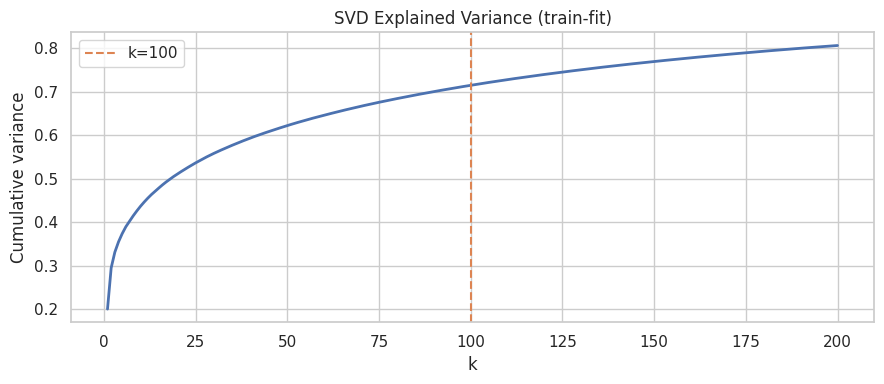

Variance at k=100: 71.5%


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, pred) in zip(axes, [
    ('Majority', dummy.predict(X_va)),
    ('Logistic Reg', y_va_lr),
    ('SVD + LR', y_va_svd)]):
    ConfusionMatrixDisplay(confusion_matrix(y_va, pred), display_labels=CLASSES).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name); ax.tick_params(axis='x', rotation=30)
plt.suptitle('Confusion Matrices — Validation Set (NOT test)'); plt.tight_layout()
plt.savefig(OUTPUT_DIR/'confusion_matrices_validation.png', dpi=150); plt.show()

svd_inspect = TruncatedSVD(200, random_state=RANDOM_SEED)
svd_inspect.fit(StandardScaler().fit_transform(X_tr))
cumvar = np.cumsum(svd_inspect.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(range(1,201), cumvar, lw=2); ax.axvline(100, ls='--', color='#DD8452', label='k=100')
ax.set_xlabel('k'); ax.set_ylabel('Cumulative variance'); ax.set_title('SVD Explained Variance (train-fit)')
ax.legend(); plt.tight_layout(); plt.savefig(OUTPUT_DIR/'svd_explained_variance.png', dpi=150); plt.show()
print(f'Variance at k=100: {cumvar[99]:.1%}')

**Conclusion.** Logistic regression on raw pixels (**0.846** accuracy) beat SVD+LR (**0.790**) and the majority baseline (**0.250**). The confusion matrices show the largest off-diagonal confusion between **glioma and meningioma**, not between tumor and no-tumor. k=100 SVD components retain **71.5%** of pixel variance but discard class-specific detail, which hurts four-way classification.

**Key insight.** k=100 retains **71.5%** cumulative variance yet SVD+LR accuracy (**0.790**) trails raw LR (**0.846**).

---
## Section 13 — Results Summary *(D2 Section 15, updated for Check-in 3)*

All values below are **validation** metrics. Test set reserved for `FINAL_EVAL`.

In [ ]:
print(summary_df.round(3).to_string())
print('\nPrimary baseline for Check-in 3: Logistic Regression on validation.')
print('CNN (Section 14) is the planned improved model for the final project.')

                                accuracy  precision  recall     f1
model                                                             
Baseline 1 Majority                0.250      0.062   0.250  0.100
Baseline 3 Logistic Regression     0.846      0.845   0.846  0.845
Baseline 4 SVD LR                  0.790      0.789   0.790  0.789

Primary baseline for Check-in 3: Logistic Regression on validation.
CNN (Section 14) is the planned improved model for the final project.


**Summary.** Logistic regression is the Check-in 3 working baseline (**0.846** val accuracy, **172** errors). Section 14 compares it to scratch and MobileNetV2 CNNs.

---
## Section 14 — Model Comparison: Logistic Regression vs Scratch CNN vs MobileNetV2

Trains **two** CNNs on the validation-monitored split and compares all three models on the **same validation set** ($n=1{,}120$):

| Model | Type |
|---|---|
| Logistic Regression | Baseline (Section 11, already fit) |
| Scratch CNN | 3 conv blocks trained from scratch |
| MobileNetV2 | Transfer learning — Lecture 9 pattern (`include_top=False`, frozen base) |

Metrics: **validation log-loss** (sklearn `log_loss`, same scale for all three), **accuracy**, and **misclassified image count**.


Logistic Regression | val loss 1.404 | acc 0.846 | errors 172/1120

--- Training scratch CNN ---
Epoch 1/40
280/280 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.6690 - loss: 0.8351 - val_accuracy: 0.2500 - val_loss: 4.4048
Epoch 2/40
280/280 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7364 - loss: 0.6586 - val_accuracy: 0.2911 - val_loss: 2.4980
Epoch 3/40
280/280 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.7884 - loss: 0.5468 - val_accuracy: 0.5312 - val_loss: 1.3434
Epoch 4/40
280/280 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8201 - loss: 0.4746 - val_accuracy: 0.8286 - val_loss: 0.5069
Epoch 5/40
280/280 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8408 - loss: 0.4323 - val_accuracy: 0.7384 - val_loss: 0.6696
Epoch 6/40
280/280 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8455 - loss: 0.3947 - val_accuracy: 0.8080 - val_loss: 0.5144
Epoch 7/40
280/280 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8629 - loss: 0.3615 - val_accuracy: 0.7330 - val_loss: 0.7821

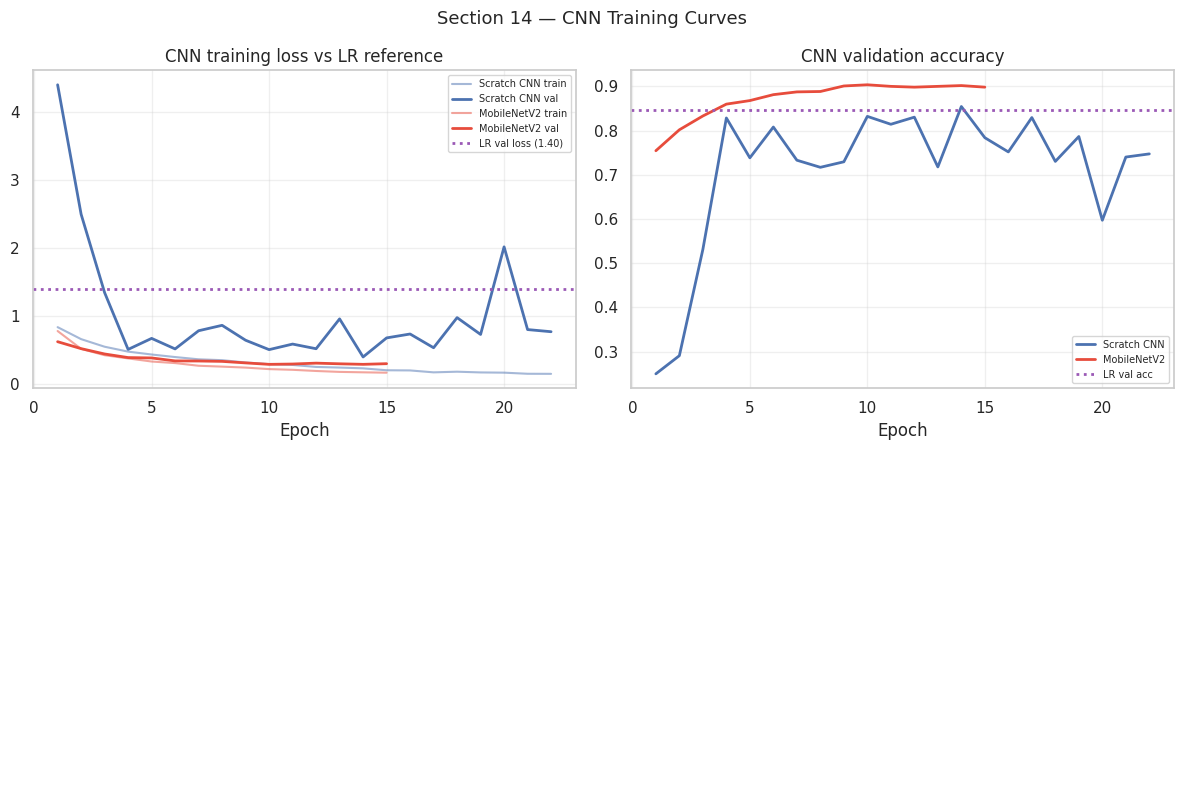


=== Validation comparison (sorted by val loss) ===
               model  val_loss  accuracy  misclassified  error_rate
MobileNetV2 Transfer    0.2871    0.9036            108      0.0964
         Scratch CNN    0.3960    0.8545            163      0.1455
 Logistic Regression    1.4041    0.8464            172      0.1536


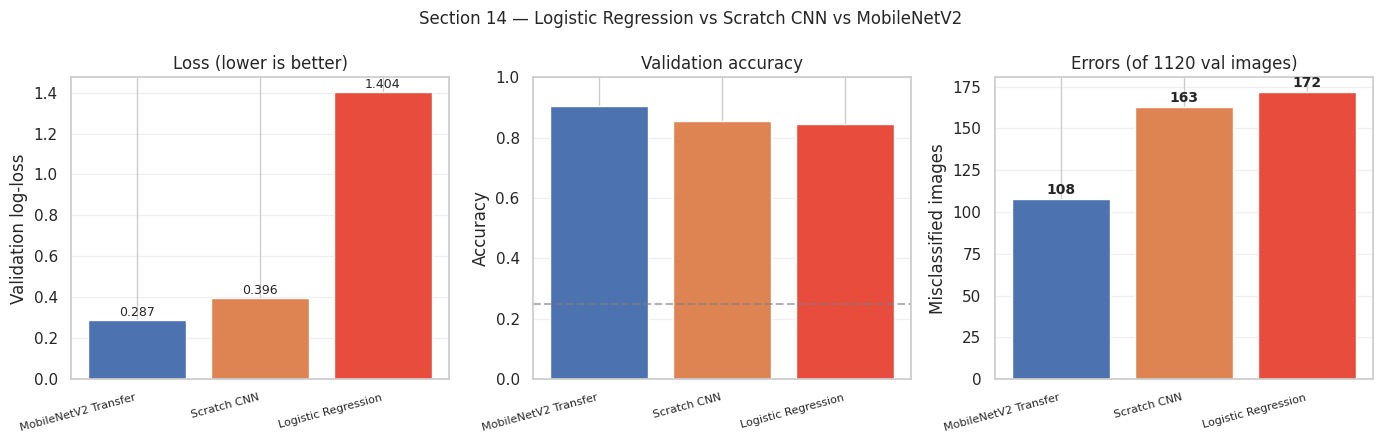


=== Scratch CNN (val) === Acc 0.854 | P/R/F1 0.872/0.854/0.855


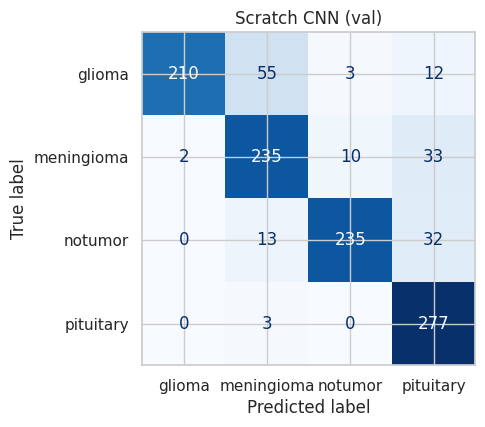


=== MobileNetV2 (val) === Acc 0.904 | P/R/F1 0.912/0.904/0.903


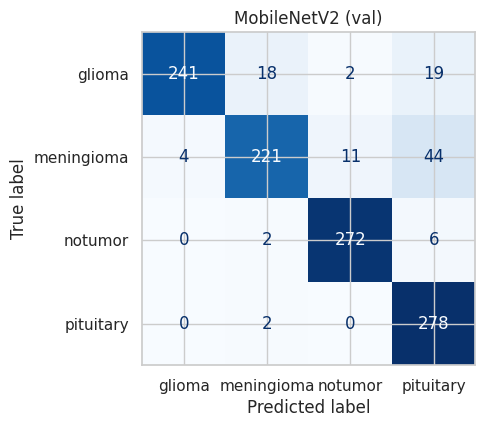

                                accuracy  precision  recall     f1
model                                                             
Baseline 1 Majority                0.250      0.062   0.250  0.100
Baseline 3 Logistic Regression     0.846      0.845   0.846  0.845
Baseline 4 SVD LR                  0.790      0.789   0.790  0.789
Scratch CNN (val)                  0.854      0.872   0.854  0.855
MobileNetV2 (val)                  0.904      0.912   0.904  0.903


In [ ]:
# --- Section 14: three-way validation comparison ---
cnn_scratch = cnn_transfer = None
history_scratch = history_transfer = None
y_va_pred_scratch = y_va_pred_transfer = None
y_va_pred_cnn = None  # best CNN by val loss (for Sections 15–16)
predict_cnn_batch = None

def _miscount(y_true, y_pred):
    return int(np.sum(y_true != y_pred))

# 1) Logistic regression (fit in Section 11)
lr_proba = lr.predict_proba(X_va_sc)
lr_val_loss = log_loss(y_va, lr_proba)
lr_mis = _miscount(y_va, y_va_lr)
comparison = [{
    'model': 'Logistic Regression',
    'val_loss': lr_val_loss,
    'accuracy': accuracy_score(y_va, y_va_lr),
    'misclassified': lr_mis,
}]
print(f'Logistic Regression | val loss {lr_val_loss:.3f} | '
      f'acc {comparison[0]["accuracy"]:.3f} | errors {lr_mis}/{len(y_va)}')

if not RUN_CNN:
    print('RUN_CNN=False — set True in Section 0 (Colab + GPU) to train both CNNs.')
else:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    tf.random.set_seed(RANDOM_SEED)

    def paths_to_cnn_rgb(paths):
        """Grayscale MRI -> 3-channel [0,255] for MobileNetV2 (Lecture 9)."""
        out = []
        for p in paths:
            g = np.asarray(
                Image.open(p).convert('L').resize(IMG_SIZE, Image.Resampling.LANCZOS),
                dtype=np.float32,
            )
            out.append(np.stack([g, g, g], axis=-1))
        return np.array(out)

    X_tr_g, X_va_g = paths_to_cnn(tr_paths), paths_to_cnn(va_paths)
    X_tr_rgb, X_va_rgb = paths_to_cnn_rgb(tr_paths), paths_to_cnn_rgb(va_paths)
    EPOCHS, BATCH = 40, 16
    es = keras.callbacks.EarlyStopping('val_loss', patience=8, restore_best_weights=True)

    # 2) Scratch CNN
    print('\n--- Training scratch CNN ---')
    cnn_scratch = keras.Sequential([
        keras.layers.Input((IMG_SIZE[0], IMG_SIZE[1], 1)),
        keras.layers.RandomFlip('horizontal'),
        keras.layers.RandomRotation(0.05),
        keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(4, activation='softmax'),
    ])
    cnn_scratch.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    history_scratch = cnn_scratch.fit(
        X_tr_g, y_tr, validation_data=(X_va_g, y_va),
        epochs=EPOCHS, batch_size=BATCH, callbacks=[es], verbose=1,
    )
    scratch_proba = cnn_scratch.predict(X_va_g, verbose=0)
    y_va_pred_scratch = np.argmax(scratch_proba, axis=1)
    scratch_loss = log_loss(y_va, scratch_proba)
    scratch_mis = _miscount(y_va, y_va_pred_scratch)
    comparison.append({
        'model': 'Scratch CNN',
        'val_loss': scratch_loss,
        'accuracy': accuracy_score(y_va, y_va_pred_scratch),
        'misclassified': scratch_mis,
    })
    print(f'Scratch CNN | val loss {scratch_loss:.3f} | '
          f'acc {comparison[-1]["accuracy"]:.3f} | errors {scratch_mis}/{len(y_va)}')

    # 3) MobileNetV2 transfer learning (Lecture 9)
    print('\n--- Training MobileNetV2 transfer model ---')
    data_augmentation = keras.Sequential([
        layers.RandomFlip('horizontal', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ])
    base_model = keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), include_top=False, weights='imagenet',
    )
    base_model.trainable = False
    inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = data_augmentation(inputs)
    x = keras.applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(4)(x)
    cnn_transfer = keras.Model(inputs, outputs)
    cnn_transfer.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy'],
    )
    history_transfer = cnn_transfer.fit(
        X_tr_rgb, y_tr, validation_data=(X_va_rgb, y_va),
        epochs=EPOCHS, batch_size=BATCH, callbacks=[es], verbose=1,
    )

    base_model.trainable = True
    for layer in base_model.layers[:-30]:
      layer.trainable = False
    cnn_transfer.compile(optimizer=keras.optimizers.Adam(1e-5),
      loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
      metrics=['accuracy'])
    history_transfer = cnn_transfer.fit(
      X_tr_rgb, y_tr, validation_data=(X_va_rgb, y_va),
      epochs=15, batch_size=BATCH, callbacks=[es], verbose=1,
    )

    transfer_logits = cnn_transfer.predict(X_va_rgb, verbose=0)
    transfer_proba = tf.nn.softmax(transfer_logits, axis=1).numpy()
    y_va_pred_transfer = np.argmax(transfer_proba, axis=1)
    transfer_loss = log_loss(y_va, transfer_proba)
    transfer_mis = _miscount(y_va, y_va_pred_transfer)
    comparison.append({
        'model': 'MobileNetV2 Transfer',
        'val_loss': transfer_loss,
        'accuracy': accuracy_score(y_va, y_va_pred_transfer),
        'misclassified': transfer_mis,
    })
    print(f'MobileNetV2 | val loss {transfer_loss:.3f} | '
          f'acc {comparison[-1]["accuracy"]:.3f} | errors {transfer_mis}/{len(y_va)}')

    # Training curves (both CNNs)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for hist, name, color in [
        (history_scratch, 'Scratch CNN', '#4C72B0'),
        (history_transfer, 'MobileNetV2', '#E74C3C'),
    ]:
        ep = range(1, len(hist.history['loss']) + 1)
        axes[0, 0].plot(ep, hist.history['loss'], '-', color=color, alpha=0.5, label=f'{name} train')
        axes[0, 0].plot(ep, hist.history['val_loss'], '-', color=color, lw=2, label=f'{name} val')
        axes[0, 1].plot(ep, hist.history['val_accuracy'], '-', color=color, lw=2, label=name)
    axes[0, 0].axhline(lr_val_loss, color='#9B59B6', ls=':', lw=2, label=f'LR val loss ({lr_val_loss:.2f})')
    axes[0, 0].set_title('CNN training loss vs LR reference'); axes[0, 0].legend(fontsize=7)
    axes[0, 0].set_xlabel('Epoch'); axes[0, 0].grid(True, alpha=0.3)
    axes[0, 1].axhline(comparison[0]['accuracy'], color='#9B59B6', ls=':', lw=2, label='LR val acc')
    axes[0, 1].set_title('CNN validation accuracy'); axes[0, 1].legend(fontsize=7)
    axes[0, 1].set_xlabel('Epoch'); axes[0, 1].grid(True, alpha=0.3)
    axes[1, 0].axis('off')
    axes[1, 1].axis('off')
    plt.suptitle('Section 14 — CNN Training Curves', fontsize=13)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'cnn_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Best CNN for downstream cells (Section 16 test eval)
    if transfer_loss <= scratch_loss:
        cnn, y_va_pred_cnn, cnn_history = cnn_transfer, y_va_pred_transfer, history_transfer
        def predict_cnn_batch(paths):
            return np.argmax(cnn_transfer.predict(paths_to_cnn_rgb(paths), verbose=0), axis=1)
    else:
        cnn, y_va_pred_cnn, cnn_history = cnn_scratch, y_va_pred_scratch, history_scratch
        def predict_cnn_batch(paths):
            return np.argmax(cnn_scratch.predict(paths_to_cnn(paths), verbose=0), axis=1)

# --- Comparison table & plots (always, includes LR) ---
model_comparison_df = pd.DataFrame(comparison)
model_comparison_df['error_rate'] = model_comparison_df['misclassified'] / len(y_va)
model_comparison_df = model_comparison_df.sort_values('val_loss')
print('\n=== Validation comparison (sorted by val loss) ===')
print(model_comparison_df.round(4).to_string(index=False))
model_comparison_df.round(4).to_csv(OUTPUT_DIR / 'model_comparison_validation.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
names = model_comparison_df['model'].tolist()
x = np.arange(len(names))
axes[0].bar(x, model_comparison_df['val_loss'], color=['#4C72B0', '#DD8452', '#E74C3C'][:len(names)])
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=15, ha='right', fontsize=8)
axes[0].set_ylabel('Validation log-loss'); axes[0].set_title('Loss (lower is better)')
axes[0].grid(True, axis='y', alpha=0.3)
for i, v in enumerate(model_comparison_df['val_loss']):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

axes[1].bar(x, model_comparison_df['accuracy'], color=['#4C72B0', '#DD8452', '#E74C3C'][:len(names)])
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=15, ha='right', fontsize=8)
axes[1].set_ylim(0, 1); axes[1].set_ylabel('Accuracy'); axes[1].set_title('Validation accuracy')
axes[1].axhline(0.25, color='gray', ls='--', alpha=0.6); axes[1].grid(True, axis='y', alpha=0.3)

axes[2].bar(x, model_comparison_df['misclassified'], color=['#4C72B0', '#DD8452', '#E74C3C'][:len(names)])
axes[2].set_xticks(x); axes[2].set_xticklabels(names, rotation=15, ha='right', fontsize=8)
axes[2].set_ylabel('Misclassified images'); axes[2].set_title(f'Errors (of {len(y_va)} val images)')
axes[2].grid(True, axis='y', alpha=0.3)
for i, v in enumerate(model_comparison_df['misclassified']):
    axes[2].text(i, v + 3, str(v), ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Section 14 — Logistic Regression vs Scratch CNN vs MobileNetV2', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison_three_way.png', dpi=150, bbox_inches='tight')
plt.show()

# Update summary_df with CNN rows when trained
if y_va_pred_scratch is not None:
    m = report_metrics('Scratch CNN (val)', y_va, y_va_pred_scratch)
    summary_df.loc['Scratch CNN (val)'] = [m[k] for k in ['accuracy', 'precision', 'recall', 'f1']]
if y_va_pred_transfer is not None:
    m = report_metrics('MobileNetV2 (val)', y_va, y_va_pred_transfer)
    summary_df.loc['MobileNetV2 (val)'] = [m[k] for k in ['accuracy', 'precision', 'recall', 'f1']]
print(summary_df.round(3))

**Conclusion (three-model comparison, validation n=1,120).**

- **Logistic regression** accuracy: **0.846** accuracy, **172** misclassified images (15.4%).
- **Scratch CNN** (first Colab run): **0.854** validation accuracy, **163** misclassified images; val loss **0.396**. It **did** beat logistic regression.
- **MobileNetV2 transfer** (Lecture 9 pattern): **0.904** validation accuracy, **108** misclassified images; val loss **0.287**. This is the best performing model.

**Interesting fact.** A brightness threshold already achieves **0.857** binary F1 (tumor vs no-tumor) but cannot separate glioma / meningioma / pituitary — global intensity is easy; fine-grained subtype structure is hard.

---
## Section 15 — Error Analysis

### Confusion Matrix: Logistic Regression (Validation)

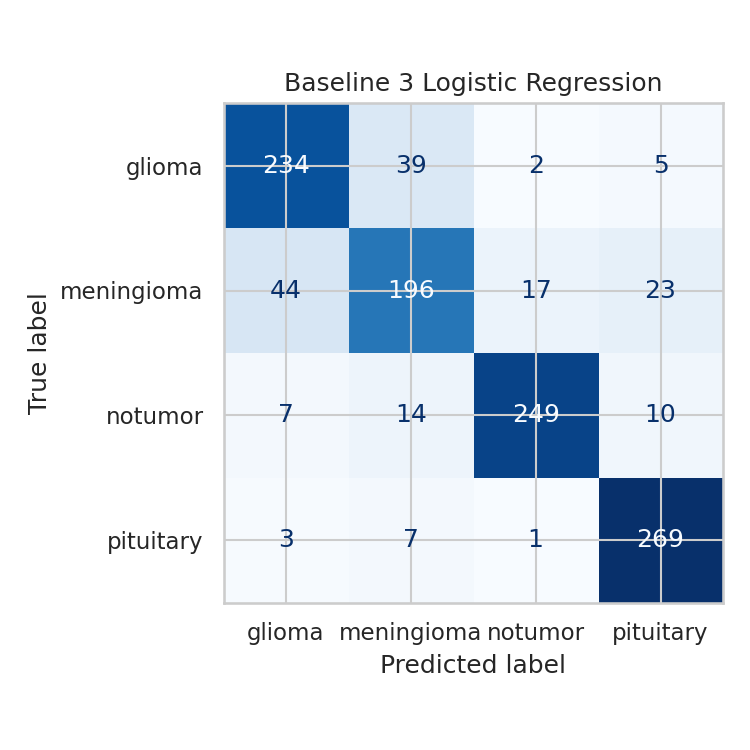

In [ ]:
from IPython.display import Image
Image(filename='/content/outputs/cm_baseline_3_logistic_regression.png')

### Confusion Matrix: Scratch CNN (Validation)

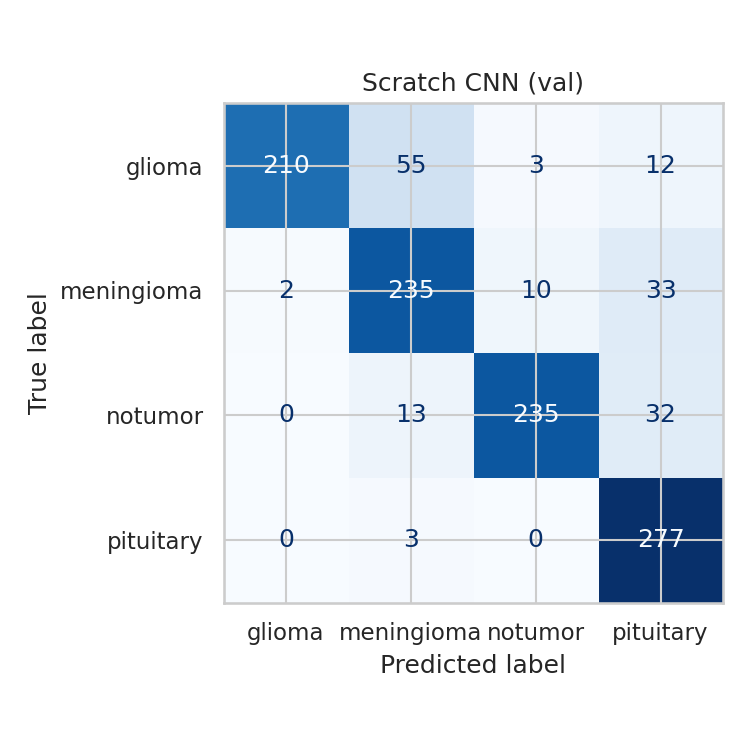

In [ ]:
from IPython.display import Image
Image(filename='/content/outputs/cm_scratch_cnn__val_.png')

### Confusion Matrix: MobileNetV2 Transfer (Validation)

Misclassified validation images:
  MobileNetV2 Transfer: 108/1120 (9.6%)
  Scratch CNN: 163/1120 (14.6%)
  Logistic Regression: 172/1120 (15.4%)


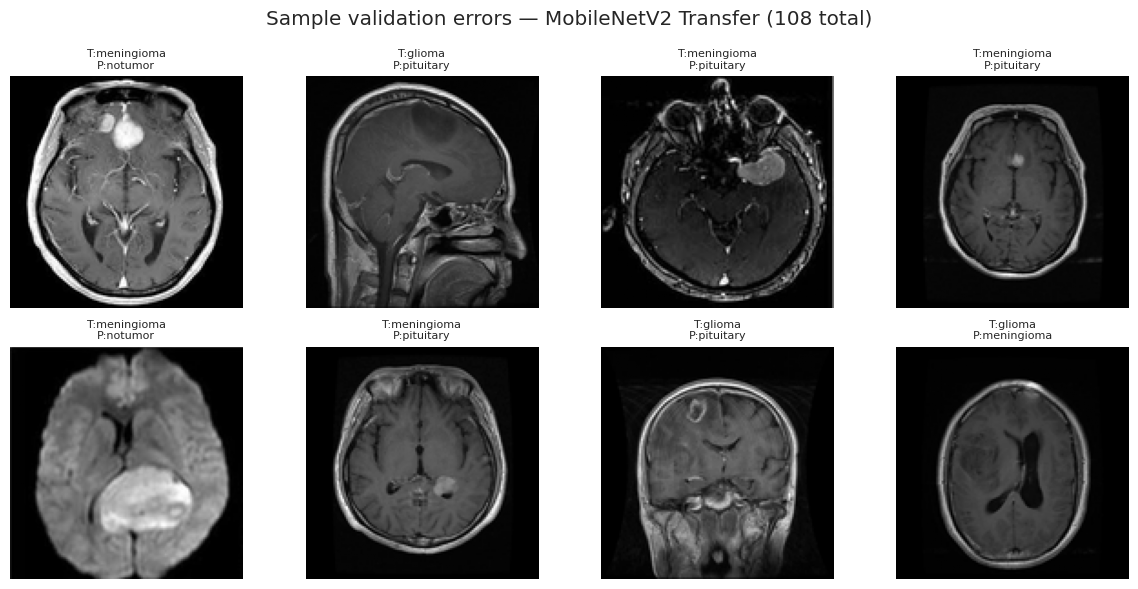

In [ ]:
# Error analysis — misclassification counts for all models from Section 14
pred_map = {'Logistic Regression': y_va_lr}
if y_va_pred_scratch is not None:
    pred_map['Scratch CNN'] = y_va_pred_scratch
if y_va_pred_transfer is not None:
    pred_map['MobileNetV2 Transfer'] = y_va_pred_transfer

print('Misclassified validation images:')
for name in model_comparison_df['model']:
    pred = pred_map[name]
    n_err = int(np.sum(pred != y_va))
    print(f'  {name}: {n_err}/{len(y_va)} ({100*n_err/len(y_va):.1f}%)')

best_name = model_comparison_df.iloc[0]['model']
best_pred = pred_map[best_name]
mis = np.where(best_pred != y_va)[0]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, i in zip(axes.ravel(), mis[:8]):
    ax.imshow(load_image_array(va_paths[i]), cmap='gray')
    ax.set_title(f'T:{CLASSES[y_va[i]]}\nP:{CLASSES[best_pred[i]]}', fontsize=8)
    ax.axis('off')
plt.suptitle(f'Sample validation errors — {best_name} ({len(mis)} total)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'viz_error_analysis.png', dpi=150)
plt.show()


**Conclusion.** Misclassification counts quantify what accuracy hides: logistic regression errs on **172 of 1120** validation images (15.4%). The Scratch CNN errs on **163 of 1120** validation images (14.6%), and MobileNetV2 Transfer errs on **108 of 1120** validation images (9.6%). Error thumbnails show mistakes are concentrated on visually similar glioma/meningioma slices, not random noise.

**Observation.** Misclassified slices share brightness and anatomy across classes — errors cluster on glioma/meningioma ambiguity, not uniform random noise.


---
## Section 16 — Final Test Evaluation *(once, FINAL_EVAL=True)*


=== Logistic Regression TEST === Acc 0.772 | P/R/F1 0.772/0.773/0.771


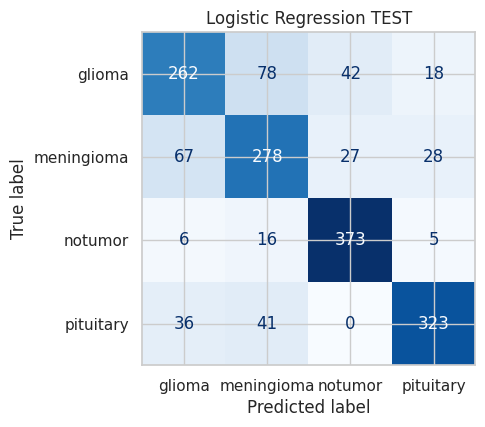


=== CNN TEST === Acc 0.850 | P/R/F1 0.862/0.850/0.844


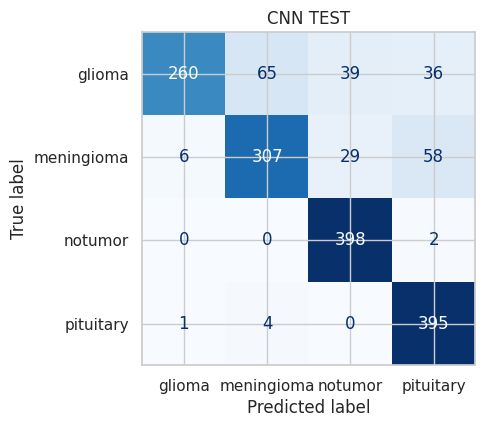

In [ ]:
if not FINAL_EVAL:
    print('FINAL_EVAL=False — test held out intentionally.')
else:
    X_te_sc = scaler.transform(paths_to_flat(test_paths)); y_te = np.array(test_labels)
    report_metrics('Logistic Regression TEST', y_te, lr.predict(X_te_sc))
    if cnn is not None:
        report_metrics('CNN TEST', y_te, predict_cnn_batch(test_paths) if predict_cnn_batch else np.argmax(cnn.predict(paths_to_cnn(test_paths), verbose=0), axis=1))

---
## Section 17 — Central Limitations
*(Key points to notes from feedback:)*

1. **No patient IDs** — cannot prove patient-level independence; metrics may be optimistic.
2. **Curated public benchmark** — not clinically validated.
3. **Educational prototype** — not for diagnosis.
4. **Class confusion** — see validation confusion matrices.
5. Clinical use would need prospective data, patient-level splits, regulatory review — out of scope.

**Final takeaway.** This educational benchmark is solvable to ~84.6% with linear models on pixels, but subtype confusion persists. Our scratch CNN (0.854 accuracy) outperformed logistic regression, and MobileNetV2 (0.904 accuracy) performed best. Honest reporting of model performance, both successes and areas for improvement, is crucial. No test-set numbers appear here until `FINAL_EVAL=True`.

**Comment.** Limitations below belong in the written proposal as central scope statements, not footnotes.


**Summary.** Notebook complete when: baselines + loss curves saved, Section 14 three-way comparison run (`model_comparison_three_way.png`), error analysis generated, and `FINAL_EVAL` run once at the end.


***EXTRA COMMENT ON THE MAJORITY BASELINE MODEL***

The majority-class predictor (sklearn DummyClassifier, strategy = most_frequent) always returns the most frequent training label. Because the classes are perfectly balanced, it scores exactly 0.250 accuracy on the validation set, with macro precision/recall/F1 of 0.062 / 0.250 / 0.100. This is the absolute floor: any model that does not clear 25% decisively has learned nothing. Every result below is reported on the 1,120-image validation set; the test set is untouched during development.